<h2> Plotting cf-gnnexplainer framework mean epoch time </h2>

In [1]:
import pandas as pd

with open('../../results/performance/final_performance.pkl', "rb") as f:
    df = pd.read_pickle(f)

df.columns

Index(['dataset', 'node_idx', 'trial', 'total_time', 'mem_before_mb',
       'mem_after_mb', 'mem_delta_mb', 'subgraph_size', 'num_edges'],
      dtype='object')

In [2]:
df

df['Mean Epoch Time (ms)'] = df['total_time'] * 10

In [3]:
grouped_stats = df.groupby(['dataset', 'node_idx']).agg({
    'total_time': 'mean',
    'subgraph_size': 'first',
    'num_edges': 'first',
}).reset_index()

grouped_stats


,dataset,node_idx,total_time,subgraph_size,num_edges
0,BACommunity Dense,0,8.547222,1208,8152
1,BACommunity Dense,1,8.776804,1193,8090
2,BACommunity Dense,2,6.591418,1028,7092
3,BACommunity Dense,3,5.445045,947,6952
4,BACommunity Dense,4,8.754133,1195,8090
...,...,...,...,...,...
8399,TreeGrid Sparse,866,0.255187,13,26
8400,TreeGrid Sparse,867,0.253182,9,18
8401,TreeGrid Sparse,868,0.252540,7,14
8402,TreeGrid Sparse,869,0.253220,9,18


In [4]:
exp_stats = df.groupby(['dataset']).agg({
    'total_time': 'mean',
    'subgraph_size': 'mean',
    'num_edges': 'mean',
}).reset_index()

exp_stats


,dataset,total_time,subgraph_size,num_edges
0,BACommunity Dense,3.066172,608.685714,4493.274286
1,BACommunity Sparse,0.637121,608.685714,4493.274286
2,BAShapes Dense,0.980433,304.400000,2212.488571
3,BAShapes Sparse,0.466576,304.400000,2212.488571
4,TreeCycle Dense,0.184400,30.694557,67.879773
5,TreeCycle Sparse,0.262227,30.694557,67.879773
6,TreeGrid Dense,0.165551,19.121699,37.983927
7,TreeGrid Sparse,0.257400,19.121699,37.983927


In [5]:
# sparse = exp_stats.loc['Sparse' in exp_stats.dataset, :]
sparse = exp_stats.loc[exp_stats.dataset.str.contains('Sparse'), :].reset_index()
dense = exp_stats.loc[exp_stats.dataset.str.contains('Dense'), :].reset_index()

dense.total_time / sparse.total_time

# str.__contains__

0    4.812544
1    2.101336
2    0.703207
3    0.643166
Name: total_time, dtype: float64

Plot saved to syn1edges.png


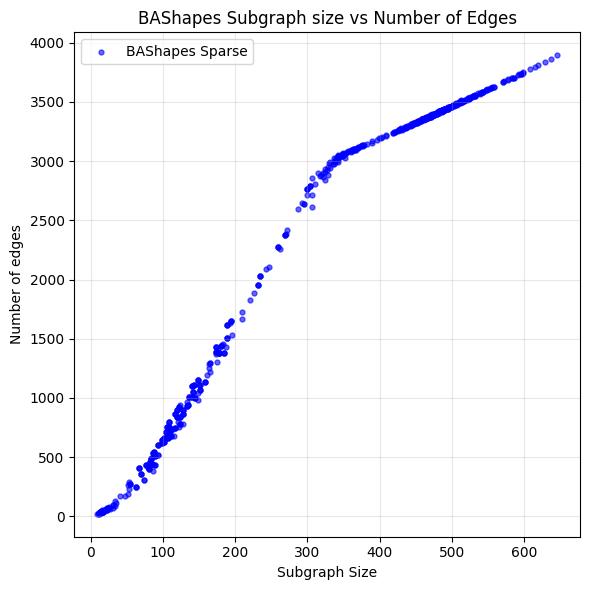

Plot saved to syn2edges.png


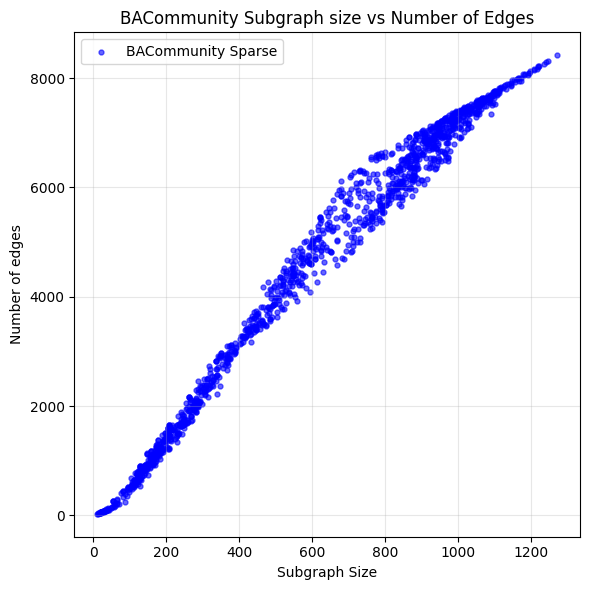

Plot saved to syn4edges.png


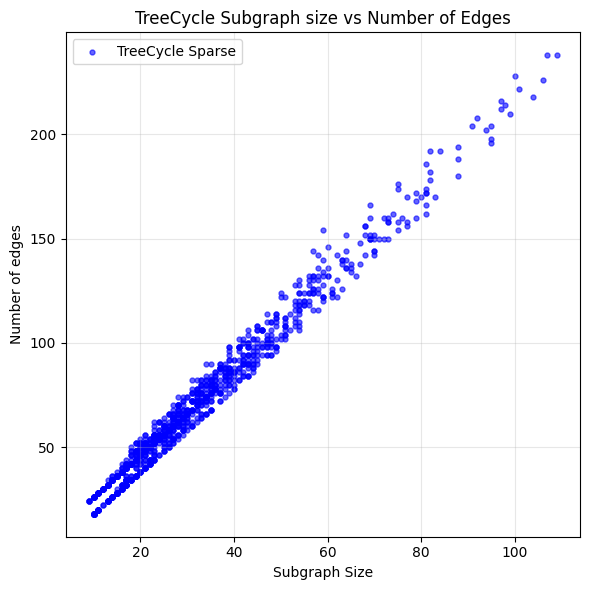

Plot saved to syn5edges.png


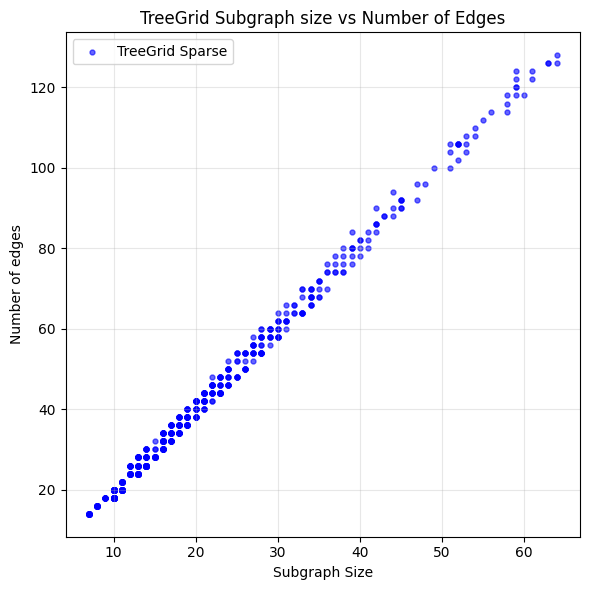

Plot saved to syn1.png


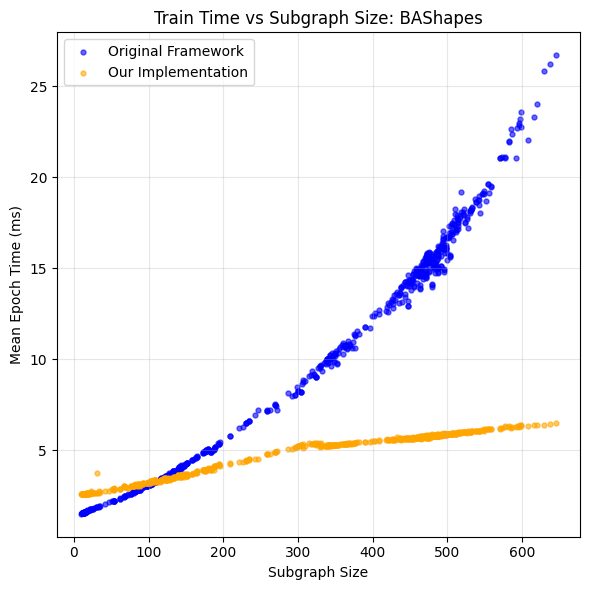

Plot saved to syn2.png


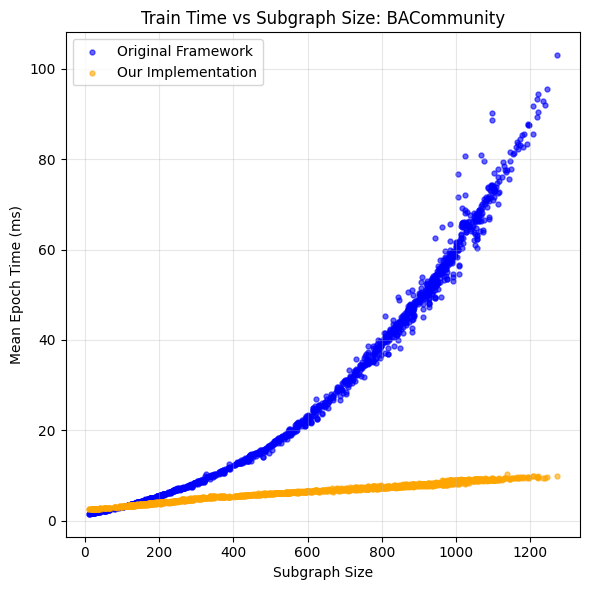

Plot saved to syn4.png


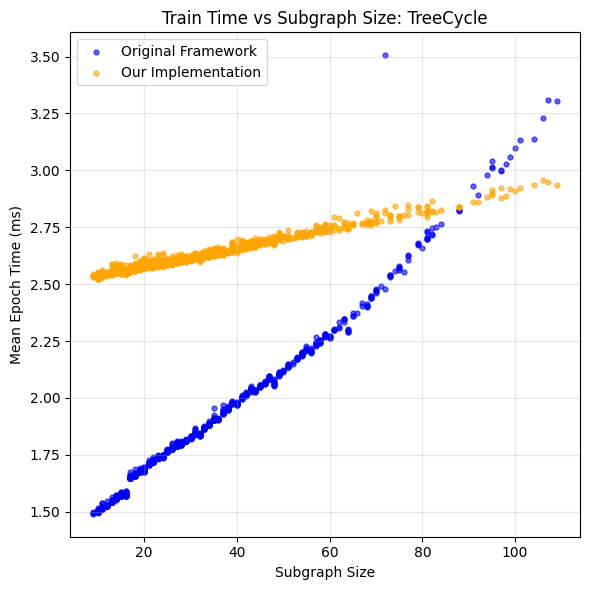

Plot saved to syn5.png


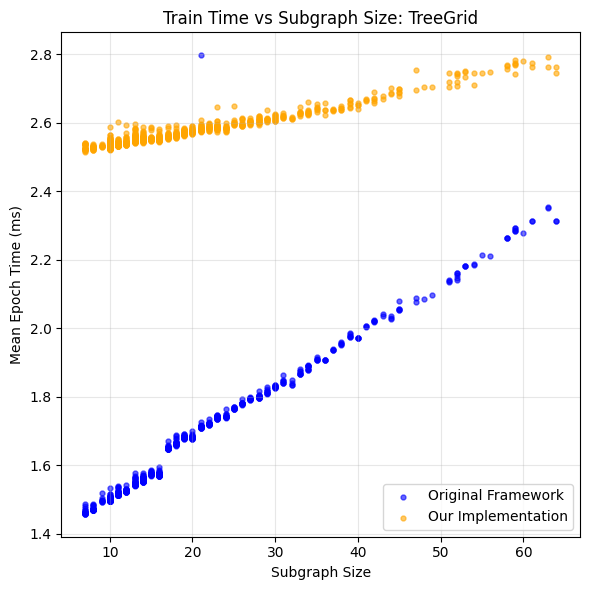

Plot saved to syn1_speedup.png


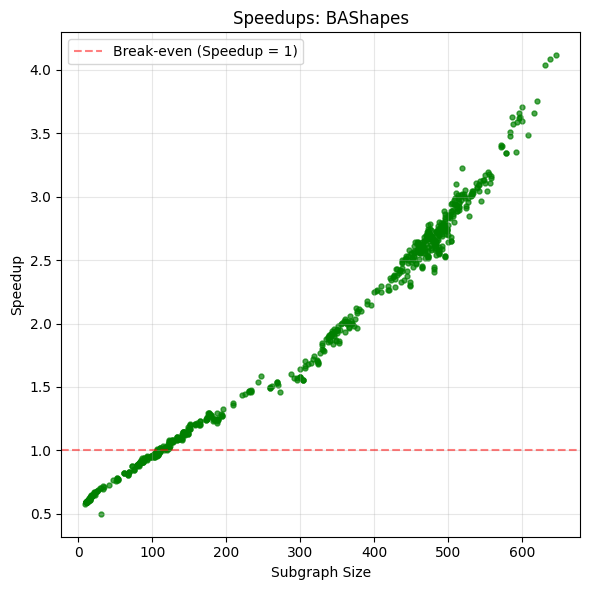

Plot saved to syn2_speedup.png


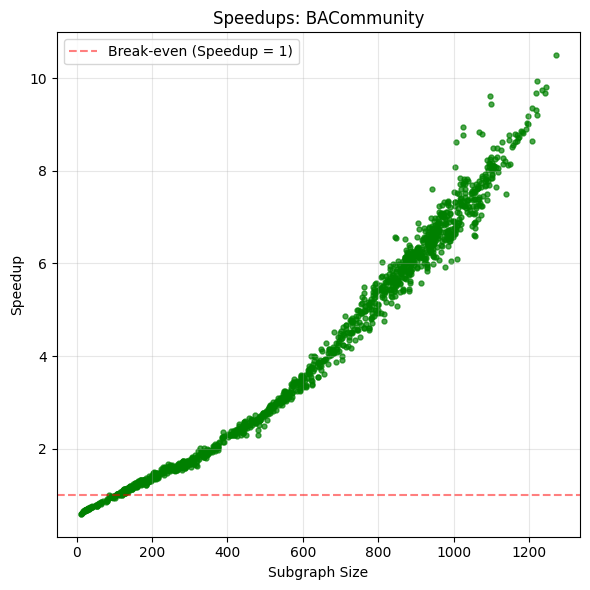

Plot saved to syn4_speedup.png


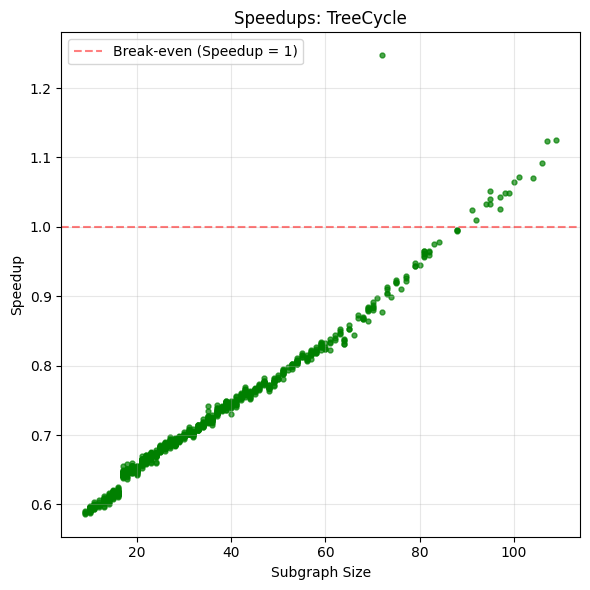

Plot saved to syn5_speedup.png


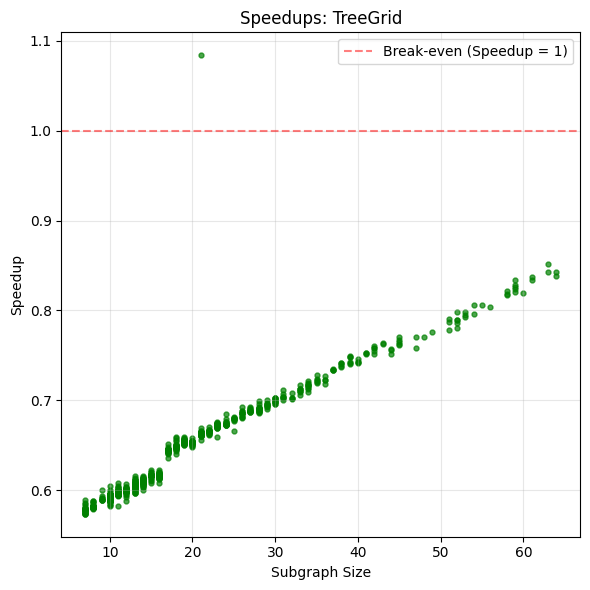

In [8]:
import matplotlib.pyplot as plt

def plot_train_time_vs_subgraph_size(df, datasets, x_axis='subgraph_size',
                                     x_label= None, y_axis='total_time',
                                     y_label= None, dst=None, title=None,
                                     scatter_names=None):
    """
    Plot training time vs subgraph size for specified datasets.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the experimental data
    datasets : list of str
        List of dataset names to plot (e.g., ['BAShapes Dense', 'BAShapes Sparse'])
    x_axis : str, optional
        Column name for x-axis (default: 'subgraph_size')
    y_axis : str, optional
        Column name for y-axis (default: 'total_time')
    dst : str or None, optional
        Destination filepath to save the plot. If None, plot is not saved (default: None)
    """
    # Filter for specified datasets
    filtered_data = df[df['dataset'].isin(datasets)]

    # Create figure
    plt.figure(figsize=(6, 6))

    # Define colors for different datasets
    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

    # Plot each dataset
    for idx, dataset_name in enumerate(datasets):
        dataset_data = filtered_data[filtered_data['dataset'] == dataset_name]
        color = colors[idx % len(colors)]

        if scatter_names is not None:
            dataset_name = scatter_names[idx]

        plt.scatter(dataset_data[x_axis], dataset_data[y_axis],
                   alpha=0.6, s=50, label=dataset_name, color=color, marker='.')

    dataset_title = datasets[0].split(' ')[0]

    plt.xlabel('Subgraph Size' if x_label is None else x_label)
    plt.ylabel('Mean Epoch Time (ms)' if y_label is None else y_label)
    plt.title(f'Train Time vs Subgraph Size: {dataset_title}' if title is None else title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Save if destination is provided
    if dst is not None:
        plt.savefig(dst, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {dst}")

    plt.show()

def plot_speedup(df, datasets, dst=None):
    # Filter for specified datasets
    filtered_data = df[df['dataset'].isin(datasets)]

    # Create figure
    plt.figure(figsize=(6, 6))

    time1 = filtered_data.loc[(filtered_data['dataset'] == datasets[0]), ['total_time', 'subgraph_size']].reset_index()
    time2 = filtered_data.loc[(filtered_data['dataset'] == datasets[1]), ['total_time', 'subgraph_size']].reset_index()

    plt.scatter(time1['subgraph_size'], time1['total_time'] / time2['total_time'],
                alpha=0.7, s=50, color='green', marker='.')
    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Break-even (Speedup = 1)')

    title = datasets[0].split(' ')[0]

    plt.xlabel('Subgraph Size')
    plt.ylabel('Speedup')
    plt.title(f'Speedups: {title}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Save if destination is provided
    if dst is not None:
        plt.savefig(dst, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {dst}")

    plt.show()

# Example usage:
plot_train_time_vs_subgraph_size(df, ['BAShapes Sparse'],    y_axis='num_edges', y_label='Number of edges', dst='syn1edges.png', title='BAShapes Subgraph size vs Number of Edges')
plot_train_time_vs_subgraph_size(df, ['BACommunity Sparse'], y_axis='num_edges', y_label='Number of edges', dst='syn2edges.png', title='BACommunity Subgraph size vs Number of Edges')
plot_train_time_vs_subgraph_size(df, ['TreeCycle Sparse'],   y_axis='num_edges', y_label='Number of edges', dst='syn4edges.png', title='TreeCycle Subgraph size vs Number of Edges')
plot_train_time_vs_subgraph_size(df, ['TreeGrid Sparse'],    y_axis='num_edges', y_label='Number of edges', dst='syn5edges.png', title='TreeGrid Subgraph size vs Number of Edges')

plot_train_time_vs_subgraph_size(df, ['BAShapes Dense', 'BAShapes Sparse'],       y_axis='Mean Epoch Time (ms)', dst='syn1.png', scatter_names=['Original Framework', 'Our Implementation'])
plot_train_time_vs_subgraph_size(df, ['BACommunity Dense', 'BACommunity Sparse'], y_axis='Mean Epoch Time (ms)', dst='syn2.png', scatter_names=['Original Framework', 'Our Implementation'])
plot_train_time_vs_subgraph_size(df, ['TreeCycle Dense', 'TreeCycle Sparse'],     y_axis='Mean Epoch Time (ms)', dst='syn4.png', scatter_names=['Original Framework', 'Our Implementation'])
plot_train_time_vs_subgraph_size(df, ['TreeGrid Dense', 'TreeGrid Sparse'],       y_axis='Mean Epoch Time (ms)', dst='syn5.png', scatter_names=['Original Framework', 'Our Implementation'])

# plot_train_time_vs_subgraph_size(df, ['TreeGrid Dense', 'TreeGrid Sparse', 'BAShapes Dense', 'BAShapes Sparse', 'TreeCycle Dense', 'TreeCycle Sparse'],       y_axis='Mean Epoch Time (ms)')

plot_speedup(df, ['BAShapes Dense', 'BAShapes Sparse'], dst='syn1_speedup.png')
plot_speedup(df, ['BACommunity Dense', 'BACommunity Sparse'], dst='syn2_speedup.png')
plot_speedup(df, ['TreeCycle Dense', 'TreeCycle Sparse'], dst='syn4_speedup.png')
plot_speedup(df, ['TreeGrid Dense', 'TreeGrid Sparse'], dst='syn5_speedup.png')


# plot_train_time_vs_subgraph_size(df, ['BAShapes Dense', 'BAShapes Sparse'], dst='bashapes_plot.png')
# plot_train_time_vs_subgraph_size(df, ['Custom Dataset 1', 'Custom Dataset 2'],
#                                   x_axis='size', y_axis='time', dst='custom_plot.pdf')
# Example usage:
# plot_train_time_vs_subgraph_size(df, ['BAShapes Dense', 'BAShapes Sparse'])
# plot_train_time_vs_subgraph_size(df, ['BAShapes Dense', 'BAShapes Sparse'], dst='bashapes_plot.png')
# plot_train_time_vs_subgraph_size(df, ['Custom Dataset 1', 'Custom Dataset 2'],
#                                   x_axis='size', y_axis='time', dst='custom_plot.pdf')